# Chest X-Ray Pneumonia (Transfer Learning Experiment )
- ### ResNet50 LR Experiment Analysis

## 1. Environment
분석 환경에 따라 프로젝트와 공통 라이브러리 경로를 설정합니다.

In [1]:
## PC 전용(기본 경로)
import sys

sys.path.insert(0, r"D:\DEV\AI\src")
sys.path.insert(0, r"D:\DEV\AI\projects\chest-xray-pneumonia")

In [3]:
import sys
import importlib

# ============================================================
# Environment
# ============================================================ 
ENV = "pc"  

# ============================================================
# Project Configuration
# ============================================================

import cxp.cxp_config as cxp_config

importlib.reload(cxp_config)

config = cxp_config.configure_environment(ENV)


# ============================================================
# Python Path
# ============================================================

PROJECT_ROOT = config["PROJECT_ROOT"]
AILIB_ROOT = config["AILIB_ROOT"]

if str(AILIB_ROOT) not in sys.path:
    sys.path.insert(0, str(AILIB_ROOT))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ============================================================
# Project Configuration
# ============================================================

DATA_ROOT = config["DATA_ROOT"]
PROCESSED_DATA_DIR = config["PROCESSED_DATA_DIR"]

TRAIN_DIR = config["TRAIN_DIR"]
VAL_DIR = config["VAL_DIR"]
TEST_DIR = config["TEST_DIR"]

IMAGE_INFO_CSV  = config["IMAGE_INFO_CSV"]

LOCAL_TRAIN_DIR = config["LOCAL_TRAIN_DIR"]
LOCAL_VAL_DIR = config["LOCAL_VAL_DIR"]
LOCAL_TEST_DIR = config["LOCAL_TEST_DIR"]

DATASET_TRAIN_DIR = config["DATASET_TRAIN_DIR"]
DATASET_VAL_DIR = config["DATASET_VAL_DIR"]
DATASET_TEST_DIR = config["DATASET_TEST_DIR"]

EXPERIMENTS_DIR = config["EXPERIMENTS_DIR"]
MODELS_DIR = config["MODELS_DIR"]
REPORTS_DIR = config["REPORTS_DIR"]

CLASS_TO_IDX = config["CLASS_TO_IDX"]
IDX_TO_CLASS = config["IDX_TO_CLASS"]


# ============================================================
# Environment Check
# ============================================================

print("=" * 60)
print("Environment Configuration")
print("=" * 60)

print(f"Environment     : {ENV}")
print(f"Project Root    : {PROJECT_ROOT}")
print(f"AI Library      : {AILIB_ROOT}")
print(f"Experiments Dir : {EXPERIMENTS_DIR}")
print(f"Reports Dir     : {REPORTS_DIR}")

print("=" * 60)

Environment Configuration
Environment     : pc
Project Root    : D:\DEV\AI\projects\chest-xray-pneumonia
AI Library      : D:\DEV\AI\src
Experiments Dir : D:\DEV\AI\projects\chest-xray-pneumonia\experiments
Reports Dir     : D:\DEV\AI\projects\chest-xray-pneumonia\reports


In [4]:
import plotly.io as pio

# 깃허브에서 보이도록 기본 렌더러를 정적 이미지로 변경
pio.renderers.default = "png" 
# 만약 화질이 깨져서 선명하게 보고 싶다면 "svg"를 사용하셔도 됩니다.

## 2. Load Reports 

In [5]:
# ============================================================
# 2. Load Experiment Reports
# ============================================================

from pathlib import Path
import pandas as pd

REPORTS_DIR = Path(REPORTS_DIR)

metadata_path = REPORTS_DIR / "experiment_metadata.csv"
history_path = REPORTS_DIR / "experiment_history.csv"

experiment_summary = pd.read_csv(metadata_path)
history_df = pd.read_csv(history_path)

print("=" * 60)
print("Loaded Experiment Reports")
print("=" * 60)

print(f"Metadata : {metadata_path}")
print(f"History  : {history_path}")

print()
print(f"Summary shape : {experiment_summary.shape}")
print(f"History shape : {history_df.shape}")

Loaded Experiment Reports
Metadata : D:\DEV\AI\projects\chest-xray-pneumonia\reports\experiment_metadata.csv
History  : D:\DEV\AI\projects\chest-xray-pneumonia\reports\experiment_history.csv

Summary shape : (14, 20)
History shape : (230, 8)


## 3. Experiment List
 

In [6]:
# ============================================================
# 3. Experiment List
# ============================================================

experiment_names = experiment_summary["experiment"].unique()

print("=" * 60)
print("Experiments")
print("=" * 60)

for i, name in enumerate(experiment_names, 1):

    runs = experiment_summary.loc[
        experiment_summary["experiment"] == name,
        "run"
    ].tolist()

    print(f"{i}. {name}")
    print(f"   Runs: {runs}")

Experiments
1. TL-DENSENET121-FULL
   Runs: ['LR1', 'LR2']
2. TL-DENSENET121-LR
   Runs: ['LR1', 'LR2']
3. TL-DENSENET121-PARTIAL
   Runs: ['LR1', 'LR2']
4. TL-RESNET50-FULL
   Runs: ['LR2', 'LR2-EPOCH20']
5. TL-RESNET50-LR
   Runs: ['LR1', 'LR2', 'LR2-EPOCH20', 'LR3']
6. TL-RESNET50-PARTIAL
   Runs: ['LR2', 'LR2-EPOCH20']


## 4.  Experiment Metadata

In [7]:
# ============================================================
# 4.  Experiment Metadata
# ============================================================

overview_columns = [
    "experiment",
    "run",
    "model",
    "image_size",
    "normalization",
    "augmentation",
    "batch_size",
    "optimizer",
    "learning_rate",
    "num_epochs",
    "best_epoch",
    "best_validation_loss",
    "best_validation_accuracy",
]

display(
    experiment_summary[overview_columns]
    .sort_values(
        ["experiment", "run"]
    )
    .reset_index(drop=True)
)

,experiment,run,model,image_size,normalization,augmentation,batch_size,optimizer,learning_rate,num_epochs,best_epoch,best_validation_loss,best_validation_accuracy
0,TL-DENSENET121-FULL,LR1,DenseNet,512,imagenet_mean_std,none,16,Adam,0.00100,20,17,0.032354,0.992337
1,TL-DENSENET121-FULL,LR2,DenseNet,512,imagenet_mean_std,none,16,Adam,0.00010,20,13,0.007616,0.996169
2,TL-DENSENET121-LR,LR1,DenseNet,512,imagenet_mean_std,none,64,Adam,0.00100,20,17,0.085301,0.969349
3,TL-DENSENET121-LR,LR2,DenseNet,512,imagenet_mean_std,none,64,Adam,0.00010,20,20,0.164848,0.944444
4,TL-DENSENET121-PARTIAL,LR1,DenseNet,512,imagenet_mean_std,none,64,Adam,0.00100,20,15,0.020797,0.995211
5,TL-DENSENET121-PARTIAL,LR2,DenseNet,512,imagenet_mean_std,none,64,Adam,0.00010,20,10,0.029739,0.990421
6,TL-RESNET50-FULL,LR2,ResNet,512,imagenet_mean_std,none,16,Adam,0.00010,10,10,0.016960,0.993295
7,TL-RESNET50-FULL,LR2-EPOCH20,ResNet,512,imagenet_mean_std,none,16,Adam,0.00010,20,7,0.018109,0.993295
8,TL-RESNET50-LR,LR1,ResNet,512,train_mean_std,none,64,Adam,0.00100,10,10,0.115350,0.954023
9,TL-RESNET50-LR,LR2,ResNet,512,train_mean_std,none,64,Adam,0.00010,10,10,0.239991,0.918582


## 5. Validation Loader

In [8]:
# ============================================================
# 5. Validation Loader
# ============================================================

import json

from ailib.data_split_v2 import split_train_validation
from ailib.transform_v2 import create_transform
from ailib.dataset_v2 import ImageDataset
from ailib.dataloader_v2 import create_dataloader


# ============================================================
# Batch Size : 실험환경에 따라 변경
# ============================================================

BATCH_SIZE = 32


# ============================================================
# Load Split Metadata
# ============================================================

split_config_path = REPORTS_DIR / "split_config.json"

if not split_config_path.exists():
    raise FileNotFoundError(
        f"Split metadata not found: {split_config_path}"
    )

with open(
    split_config_path,
    "r",
    encoding="utf-8",
) as f:
    split_config = json.load(f)


# ============================================================
# Split Configuration
# ============================================================

VAL_SIZE = split_config["validation"]["size"]
RANDOM_STATE = split_config["validation"]["random_state"]
STRATIFY_COLUMN = split_config["validation"]["stratify_column"]


# ============================================================
# Preprocessing Configuration
# ============================================================

IMAGE_SIZE = split_config["preprocessing"]["image_size"]
NORMALIZATION = split_config["preprocessing"]["normalization"]


# ============================================================
# Load Dataset Metadata
# ============================================================

image_info = pd.read_csv(IMAGE_INFO_CSV)


# ============================================================
# Recreate Train / Validation Split
# ============================================================

train_df, val_df = split_train_validation(
    dataframe=image_info,
    val_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify_column=STRATIFY_COLUMN,
)


# ============================================================
# Validation Transform
# ============================================================

eval_transform = create_transform(
    image_size=IMAGE_SIZE,
    mean=NORMALIZATION["mean"],
    std=NORMALIZATION["std"],
)


# ============================================================
# Validation Dataset
# ============================================================

val_dataset = ImageDataset(
    dataframe=val_df,
    data_dir=DATASET_TRAIN_DIR,
    class_to_idx=CLASS_TO_IDX,
    transform=eval_transform,
)


# ============================================================
# Validation DataLoader
# ============================================================

val_loader = create_dataloader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


# ============================================================
# Result
# ============================================================

print("=" * 60)
print("Validation Loader")
print("=" * 60)

print(f"Split Version : {split_config['version']}")
print(f"Validation    : {len(val_dataset)}")
print(f"Image Size    : {IMAGE_SIZE}")
print(f"Batch Size    : {BATCH_SIZE}")
print(f"Shuffle       : False")
print("=" * 60)

Validation Loader
Split Version : 1.0
Validation    : 1044
Image Size    : 512
Batch Size    : 32
Shuffle       : False


##  Analysis 

### 1. Analysis Configuration

In [9]:
# ============================================================
# Analysis
# 1. Analysis Configuration
# ============================================================

import json
from pathlib import Path

import pandas as pd
import torch
from ailib.device import get_device


# ------------------------------------------------------------
# Analysis settings
# ------------------------------------------------------------

SELECTED_EXPERIMENTS = [
    "TL-RESNET50-LR",
]

DEVICE = get_device() 


print(f"Device: {DEVICE}")
print(f"Selected Experiments: {SELECTED_EXPERIMENTS}")

Device: cuda
Selected Experiments: ['TL-RESNET50-LR']


### 2. Experiment Selection

In [11]:
# ============================================================
# 2. Experiment Selection
# ============================================================

selected_summary = experiment_summary[
    experiment_summary["experiment"].isin(SELECTED_EXPERIMENTS)
].copy()

selected_summary = (
    selected_summary
    .sort_values(["experiment", "run"])
    .reset_index(drop=True)
)

print(
    f"Experiments: {selected_summary['experiment'].nunique()}"
)
print(
    f"Runs: {len(selected_summary)}"
)

display(
    selected_summary[
        ["experiment", "run", "model", "learning_rate", "num_epochs"]
    ]
)

Experiments: 1
Runs: 4


,experiment,run,model,learning_rate,num_epochs
0,TL-RESNET50-LR,LR1,ResNet,0.00100,10
1,TL-RESNET50-LR,LR2,ResNet,0.00010,10
2,TL-RESNET50-LR,LR2-EPOCH20,ResNet,0.00010,20
3,TL-RESNET50-LR,LR3,ResNet,0.00001,10


### 3. Selected Experiment Overview

In [12]:
# ============================================================
# 3. Selected Experiment Overview
# ============================================================

overview_columns = [
    "experiment",
    "run",
    "model",
    "image_size",
    "normalization",
    "augmentation",
    "batch_size",
    "optimizer",
    "learning_rate",
    "num_epochs",
    "best_epoch",
    "best_validation_loss",
    "best_validation_accuracy",
]

available_columns = [
    column
    for column in overview_columns
    if column in selected_summary.columns
]

display(
    selected_summary[
        available_columns
    ].reset_index(drop=True)
)

,experiment,run,model,image_size,normalization,augmentation,batch_size,optimizer,learning_rate,num_epochs,best_epoch,best_validation_loss,best_validation_accuracy
0,TL-RESNET50-LR,LR1,ResNet,512,train_mean_std,none,64,Adam,0.00100,10,10,0.115350,0.954023
1,TL-RESNET50-LR,LR2,ResNet,512,train_mean_std,none,64,Adam,0.00010,10,10,0.239991,0.918582
2,TL-RESNET50-LR,LR2-EPOCH20,ResNet,512,imagenet_mean_std,none,64,Adam,0.00010,20,20,0.182429,0.936782
3,TL-RESNET50-LR,LR3,ResNet,512,train_mean_std,none,64,Adam,0.00001,10,10,0.528539,0.743295


### 4. Validation Evaluation

#### 4-1. Model Load

In [13]:
# ============================================================
# 4. Validation Evaluation
# 4-1. Model Load
# ============================================================

from cxp.cxp_model import (
    build_transfer_model,
    configure_fine_tuning,
)


def load_experiment_model(run_info):
    """
    Load a trained experiment model using experiment metadata.
    """

    experiment = run_info["experiment"]
    run = run_info["run"]

    model_path = (
        EXPERIMENTS_DIR
        / experiment
        / run
        / "model.pth"
    )

    # ========================================================
    # Model Configuration
    # ========================================================

    model_name = run_info["model"]
    channels = run_info["channels"]

    # Metadata model name → model builder name
    if model_name == "ResNet":
        model_name = "resnet50"

    # ========================================================
    # Build Model
    # ========================================================

    model = build_transfer_model(
        model_name=model_name,
        num_classes=2,
        in_channels=channels,
        pretrained=True,
    )

    # ========================================================
    # Configure Model
    # ========================================================

    model = configure_fine_tuning(
        model=model,
        model_name=model_name,
        fine_tuning_mode="frozen",
    )

    # ========================================================
    # Load Checkpoint
    # ========================================================

    checkpoint = torch.load(
        model_path,
        map_location=DEVICE,
    )

    model.load_state_dict(checkpoint)

    model = model.to(DEVICE)
    model.eval()

    return model

#### 4-2. Run Evaluation

In [ ]:
# ============================================================
# 4-2. Run Evaluation
# ============================================================

from cxp.cxp_evaluation import (
    predict,
    calculate_metrics,
    save_validation_result,
)

validation_results = []
validation_predictions = {}

for _, run_info in selected_summary.iterrows():

    experiment = run_info["experiment"]
    run = run_info["run"]

    print(
        f"Evaluating: {experiment} / {run}"
    )

    # --------------------------------------------------------
    # Load Model
    # --------------------------------------------------------

    model = load_experiment_model(
        run_info
    )

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    labels, predictions, probabilities = predict(
        model=model,
        loader=val_loader,
        device=DEVICE,
    )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    metrics = calculate_metrics(
        labels=labels,
        predictions=predictions,
        probabilities=probabilities,
    )

    validation_results.append({
        "experiment": experiment,
        "run": run,
        **metrics,
    })

    # --------------------------------------------------------
    # Store Predictions
    # --------------------------------------------------------

    validation_predictions[(experiment, run)] = {
        "labels": labels,
        "predictions": predictions,
        "probabilities": probabilities,
    }

    # --------------------------------------------------------
    # Save Validation Result
    # --------------------------------------------------------

    run_path = EXPERIMENTS_DIR / experiment / run

    validation_path = save_validation_result(
        run_path=run_path,
        experiment=experiment,
        run=run,
        labels=labels,
        predictions=predictions,
        probabilities=probabilities,
        metrics=metrics,
    )

    print(f"Saved: {validation_path}")

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del model

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

Evaluating: TL-RESNET50-LR / LR1
Evaluating: TL-RESNET50-LR / LR2
Evaluating: TL-RESNET50-LR / LR2-EPOCH20
Evaluating: TL-RESNET50-LR / LR3


#### 4-3. Validation Metrics

In [15]:
# ============================================================
# 4-3. Validation Metrics
# ============================================================

validation_results_df = pd.DataFrame(
    validation_results
)


metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "roc_auc",
]

display(
    validation_results_df[
        ["experiment", "run"] + metric_columns
    ]
    .sort_values(
        ["experiment", "run"]
    )
    .reset_index(drop=True)
)

,experiment,run,accuracy,precision,recall,specificity,f1,roc_auc
0,TL-RESNET50-LR,LR1,0.954023,0.973958,0.963918,0.925373,0.968912,0.990725
1,TL-RESNET50-LR,LR2,0.918582,0.945806,0.944588,0.843284,0.945197,0.971510
2,TL-RESNET50-LR,LR2-EPOCH20,0.936782,0.967105,0.947165,0.906716,0.957031,0.981430
3,TL-RESNET50-LR,LR3,0.743295,0.743295,1.000000,0.000000,0.852747,0.826392


In [16]:
# ============================================================
# Validation Metrics - Percentage View
# ============================================================

display(
    validation_results_df[
        ["experiment", "run"] + metric_columns
    ]
    .style
    .format({
        column: "{:.4f}"
        for column in metric_columns
    })
)

,experiment,run,accuracy,precision,recall,specificity,f1,roc_auc
0,TL-RESNET50-LR,LR1,0.9540,0.9740,0.9639,0.9254,0.9689,0.9907
1,TL-RESNET50-LR,LR2,0.9186,0.9458,0.9446,0.8433,0.9452,0.9715
2,TL-RESNET50-LR,LR2-EPOCH20,0.9368,0.9671,0.9472,0.9067,0.9570,0.9814
3,TL-RESNET50-LR,LR3,0.7433,0.7433,1.0000,0.0000,0.8527,0.8264


In [17]:
# ============================================================
# Confusion Matrix Counts
# ============================================================

confusion_columns = [
    "tn",
    "fp",
    "fn",
    "tp",
]

display(
    validation_results_df[
        ["experiment", "run"] + confusion_columns
    ]
    .sort_values(
        ["experiment", "run"]
    )
    .reset_index(drop=True)
)

,experiment,run,tn,fp,fn,tp
0,TL-RESNET50-LR,LR1,248,20,28,748
1,TL-RESNET50-LR,LR2,226,42,43,733
2,TL-RESNET50-LR,LR2-EPOCH20,243,25,41,735
3,TL-RESNET50-LR,LR3,0,268,0,776


### 5. Experiment Comparison

#### 5-1. Classification Metrics

In [ ]:
# # ============================================================
# # 5. Experiment Comparison
# # 5-1. Classification Metrics
# # ============================================================

# # import importlib
# # import cxp.cxp_plot as cxp_plot

# # importlib.reload(cxp_plot)

# cxp_plot.plot_metric_comparison(
#     validation_results_df
# )

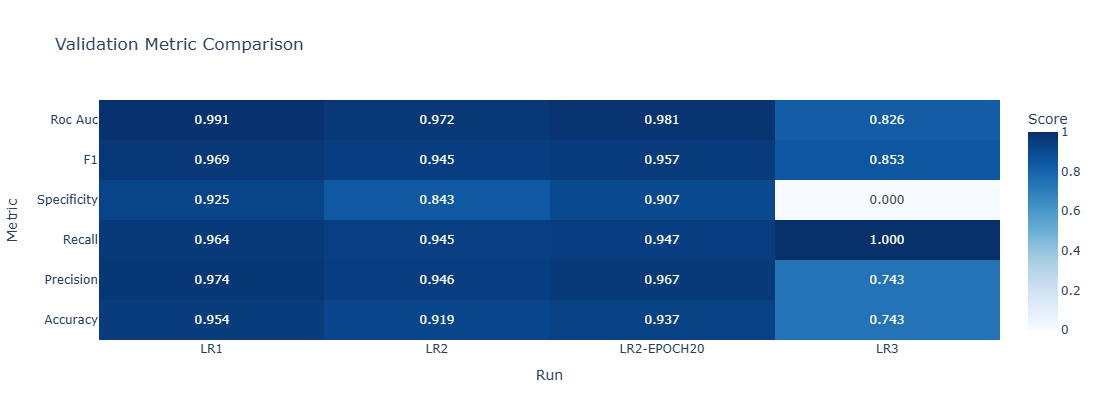

In [18]:
# ============================================================
# 5. Experiment Comparison
# 5-1. Classification Metrics
# ============================================================

import importlib
import cxp.cxp_plot as cxp_plot

importlib.reload(cxp_plot)

cxp_plot.plot_metric_comparison(
    validation_results_df
)

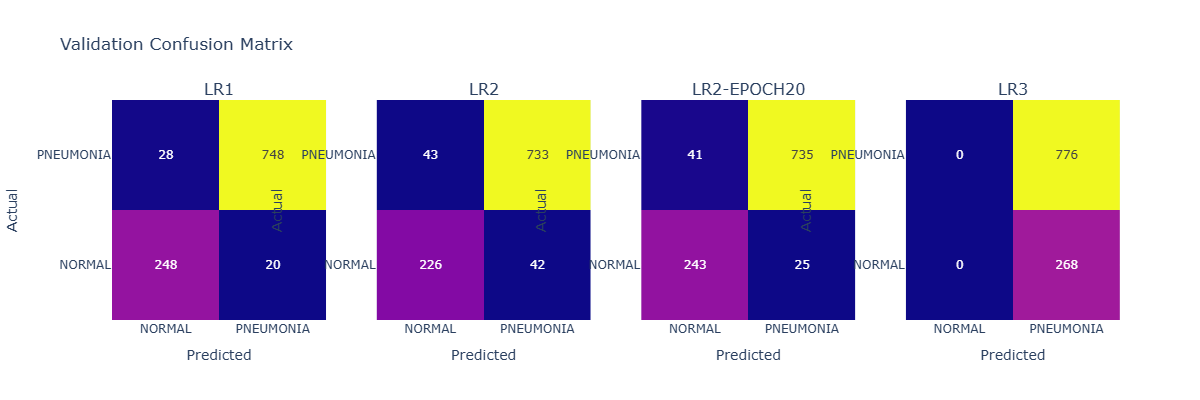

In [20]:
# ============================================================
# 5-2. Confusion Matrix
# ============================================================

cxp_plot.plot_confusion_matrix_comparison(
    validation_results_df
)
 

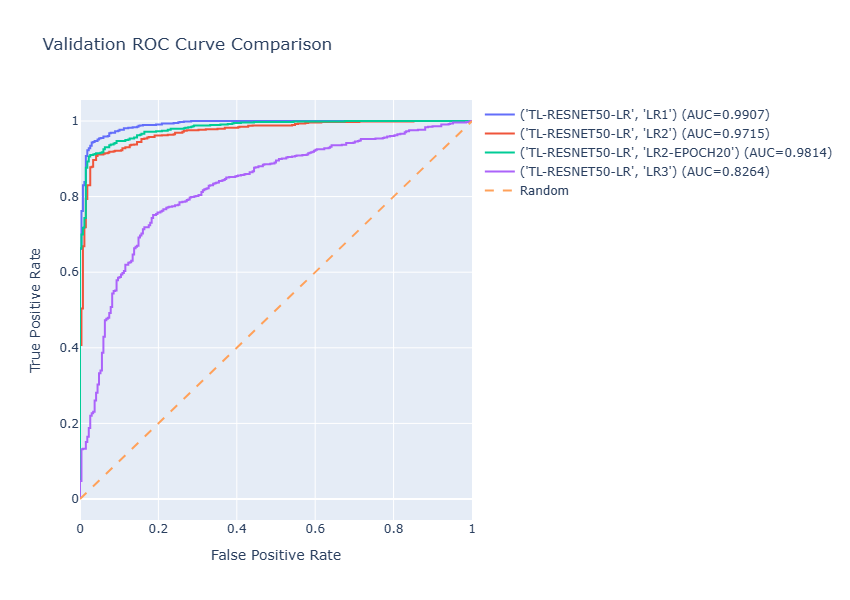

In [21]:
# ============================================================
# 5-3. ROC Curve
# ============================================================

cxp_plot.plot_roc_curve_comparison(
    validation_predictions
)

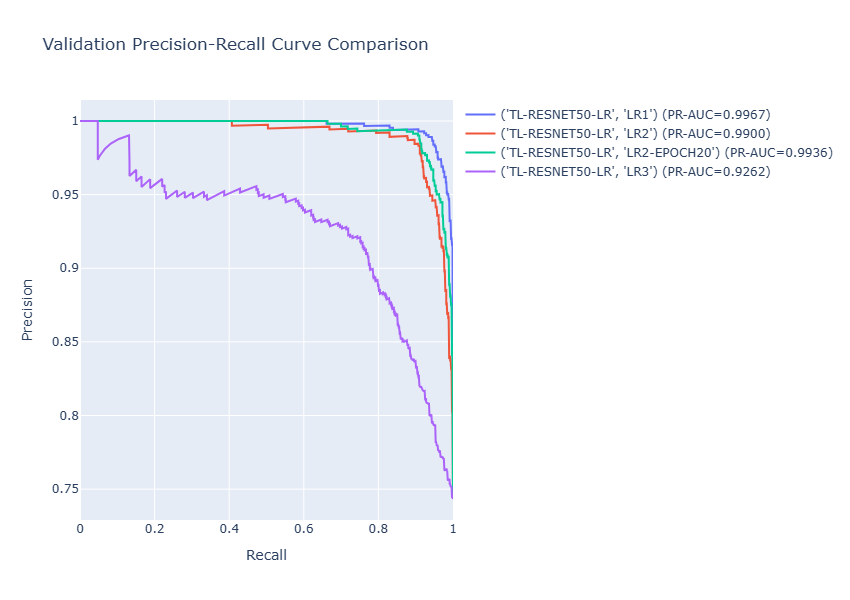

In [22]:
# ============================================================
# 5-4. PR Curve
# ============================================================

cxp_plot.plot_pr_curve_comparison(
    validation_predictions
)

### 6. Learning Curve — Loss

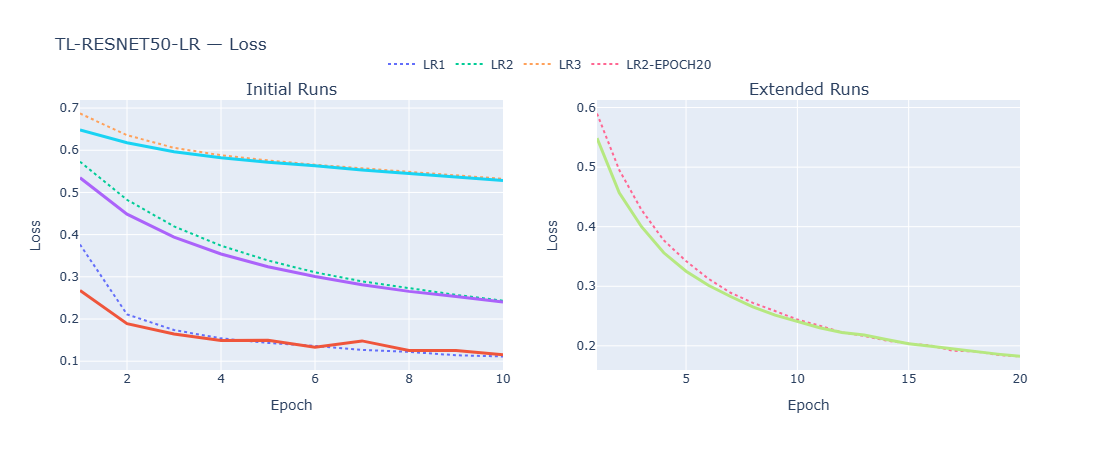

In [23]:
# ============================================================
# 6. Learning Curve
# 6-1. Validation Loss
# ============================================================

experiment_name = SELECTED_EXPERIMENTS[0]

experiment_history = history_df[
    history_df["experiment"] == experiment_name
].copy()

cxp_plot.plot_experiment_history(
    history=experiment_history,
    experiment_name=experiment_name,
    metric="loss",
)

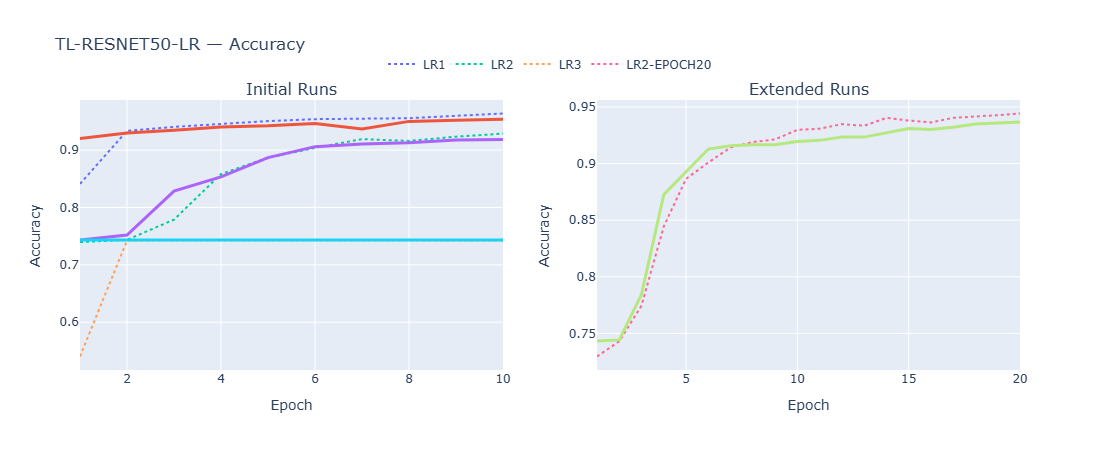

In [24]:
# ============================================================
# 6-2. Validation Accuracy
# ============================================================

cxp_plot.plot_experiment_history(
    history=experiment_history,
    experiment_name=experiment_name,
    metric="accuracy",
)

### 7. Error Analysis

#### -1-1. FP / FN Data

In [25]:
# ============================================================
# 7-1. Error Analysis
# 7-1-1. FP / FN Data
# ============================================================
 
ERROR_EXPERIMENT = "TL-RESNET50-LR"
ERROR_RUN = "LR2-EPOCH20"

prediction_result = validation_predictions[
    (ERROR_EXPERIMENT, ERROR_RUN)
]

error_df = val_df.copy().reset_index(drop=True)

error_df["y_true"] = prediction_result["labels"]
error_df["y_pred"] = prediction_result["predictions"]
error_df["y_prob"] = prediction_result["probabilities"]

# ------------------------------------------------------------
# False Positive
# Actual: NORMAL
# Predicted: PNEUMONIA
# ------------------------------------------------------------

fp_df = error_df[
    (error_df["y_true"] == 0)
    & (error_df["y_pred"] == 1)
].copy()

# ------------------------------------------------------------
# False Negative
# Actual: PNEUMONIA
# Predicted: NORMAL
# ------------------------------------------------------------

fn_df = error_df[
    (error_df["y_true"] == 1)
    & (error_df["y_pred"] == 0)
].copy()

print(f"Run: {ERROR_RUN}")
print(f"False Positive: {len(fp_df)}")
print(f"False Negative: {len(fn_df)}")

Run: LR2-EPOCH20
False Positive: 25
False Negative: 41


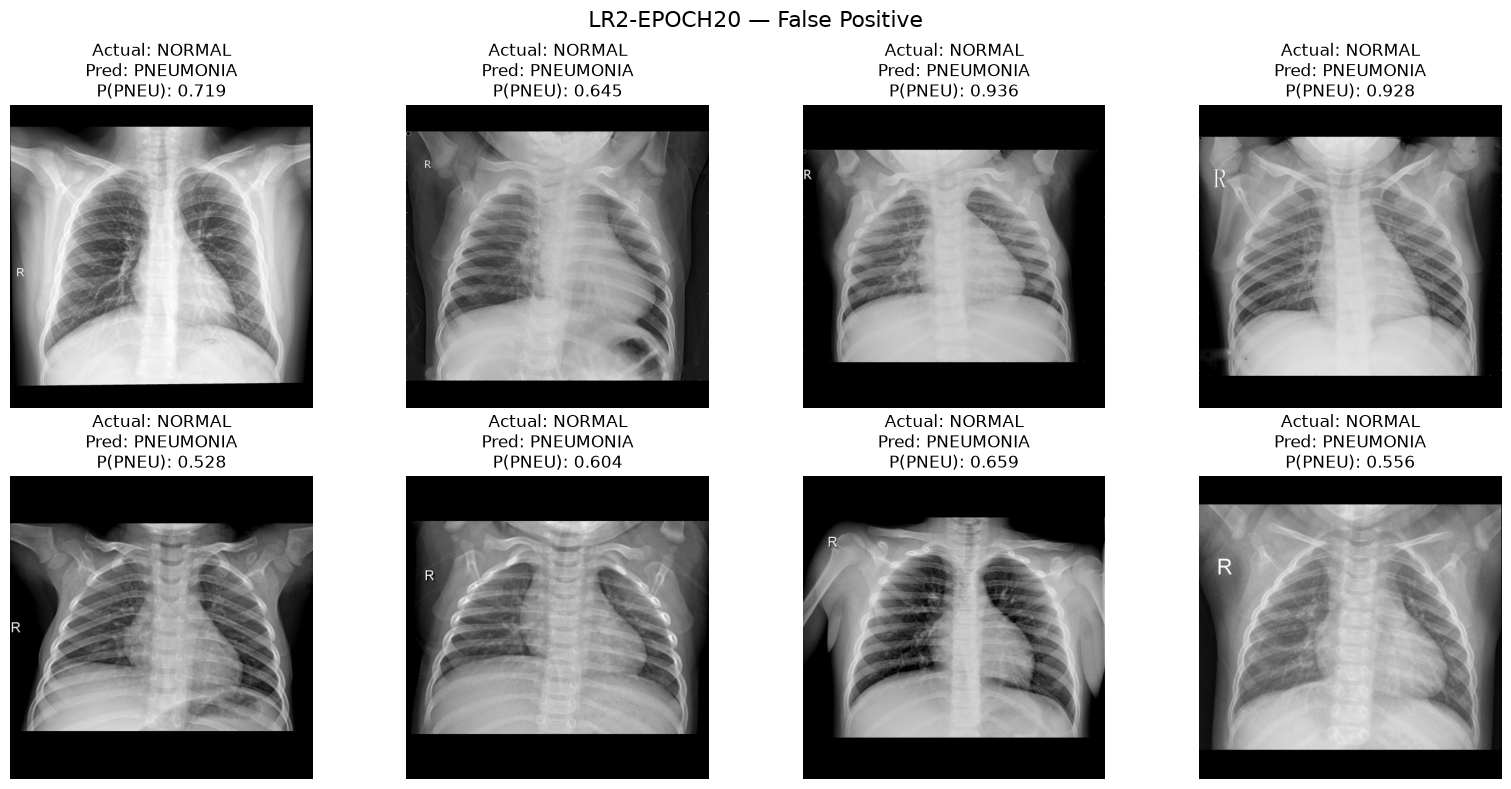

In [26]:
# ============================================================
# 7-1-2. False Positive
# ============================================================

cxp_plot.show_error_images(
    dataframe=fp_df,
    data_dir=DATASET_TRAIN_DIR,
    idx_to_class=IDX_TO_CLASS,
    n=8,
    title=f"{ERROR_RUN} — False Positive",
)

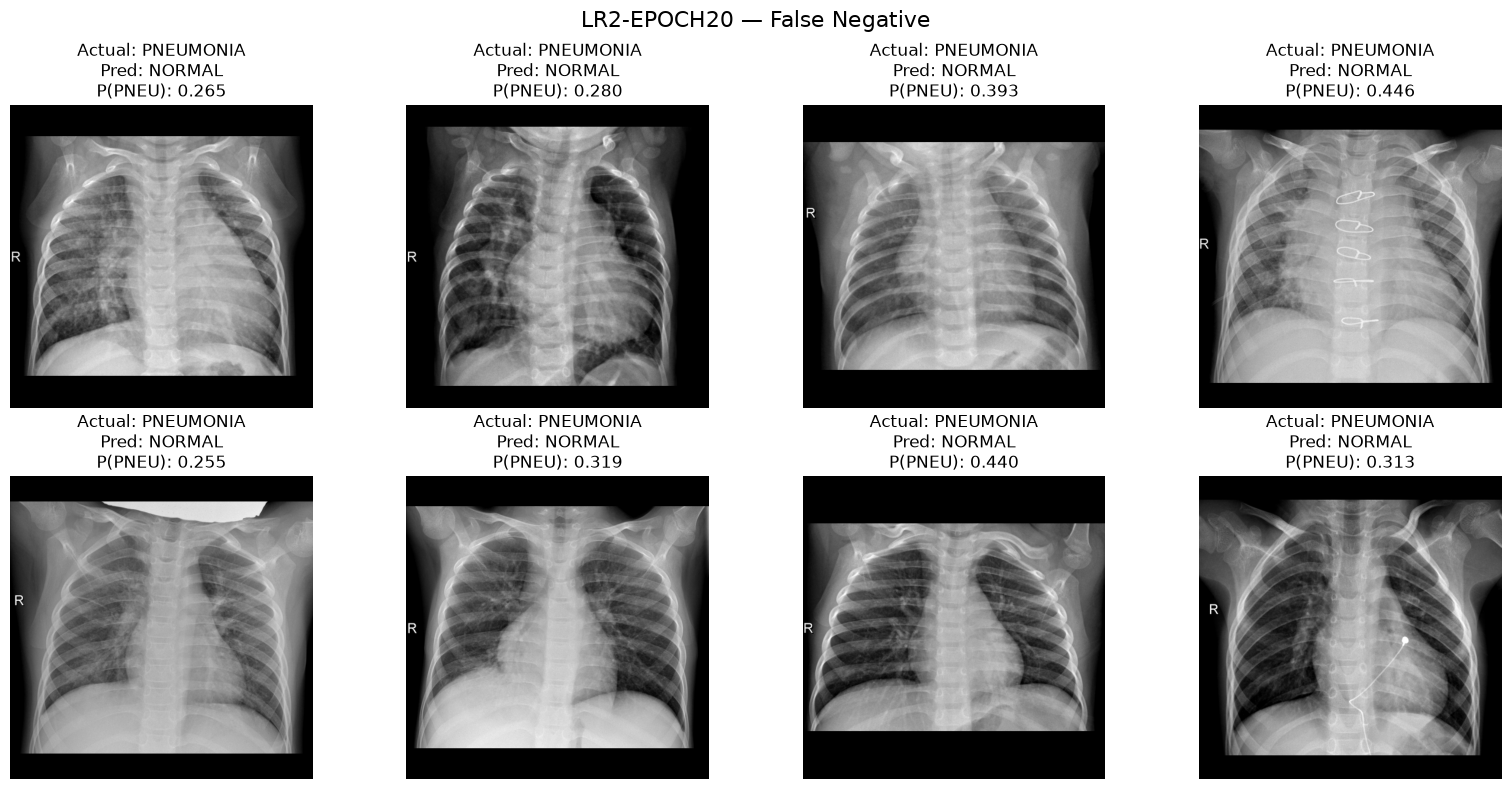

In [27]:
# ============================================================
# 7-1-3. False Negative
# ============================================================

cxp_plot.show_error_images(
    dataframe=fn_df,
    data_dir=DATASET_TRAIN_DIR,
    idx_to_class=IDX_TO_CLASS,
    n=8,
    title=f"{ERROR_RUN} — False Negative",
)

#### 7-2. Confidence-based Error Analysis

In [28]:
# ============================================================
# 7-2. Confidence-based Error Analysis
# ============================================================

# ------------------------------------------------------------
# False Positive
# Actual: NORMAL
# Predicted: PNEUMONIA
# ------------------------------------------------------------

fp_df = fp_df.copy()

fp_df["confidence"] = fp_df["y_prob"]

fp_high_conf = (
    fp_df
    .sort_values(
        "confidence",
        ascending=False,
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# False Negative
# Actual: PNEUMONIA
# Predicted: NORMAL
# ------------------------------------------------------------

fn_df = fn_df.copy()

fn_df["confidence"] = 1 - fn_df["y_prob"]

fn_high_conf = (
    fn_df
    .sort_values(
        "confidence",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(f"Run: {ERROR_RUN}")

print(f"\nFalse Positive: {len(fp_high_conf)}")
display(
    fp_high_conf[
        ["Folder", "File", "y_true", "y_pred", "y_prob", "confidence"]
    ].head(10)
)

print(f"\nFalse Negative: {len(fn_high_conf)}")
display(
    fn_high_conf[
        ["Folder", "File", "y_true", "y_pred", "y_prob", "confidence"]
    ].head(10)
)

Run: LR2-EPOCH20

False Positive: 25


,Folder,File,y_true,y_pred,y_prob,confidence
0,NORMAL,NORMAL2-IM-1250-0001.png,0,1,0.935821,0.935821
1,NORMAL,NORMAL2-IM-0790-0001.png,0,1,0.927605,0.927605
2,NORMAL,NORMAL2-IM-1365-0001.png,0,1,0.922161,0.922161
3,NORMAL,NORMAL2-IM-0611-0001.png,0,1,0.910279,0.910279
4,NORMAL,NORMAL2-IM-1371-0001.png,0,1,0.768088,0.768088
5,NORMAL,NORMAL2-IM-0904-0001.png,0,1,0.718561,0.718561
6,NORMAL,IM-0517-0001.png,0,1,0.659166,0.659166
7,NORMAL,NORMAL2-IM-0723-0001.png,0,1,0.645295,0.645295
8,NORMAL,NORMAL2-IM-0600-0001.png,0,1,0.645182,0.645182
9,NORMAL,NORMAL2-IM-1123-0001.png,0,1,0.643905,0.643905



False Negative: 41


,Folder,File,y_true,y_pred,y_prob,confidence
0,PNEUMONIA,person328_bacteria_1510.png,1,0,0.116698,0.883302
1,PNEUMONIA,person348_bacteria_1604.png,1,0,0.157376,0.842624
2,PNEUMONIA,person702_virus_1299.png,1,0,0.187368,0.812632
3,PNEUMONIA,person5_bacteria_15.png,1,0,0.201351,0.798649
4,PNEUMONIA,person620_bacteria_2492.png,1,0,0.208406,0.791594
5,PNEUMONIA,person1151_virus_1928.png,1,0,0.210951,0.789049
6,PNEUMONIA,person1261_bacteria_3219.png,1,0,0.220668,0.779332
7,PNEUMONIA,person314_bacteria_1461.png,1,0,0.226311,0.773689
8,PNEUMONIA,person781_virus_1412.png,1,0,0.239281,0.760719
9,PNEUMONIA,person277_virus_571.png,1,0,0.255478,0.744522


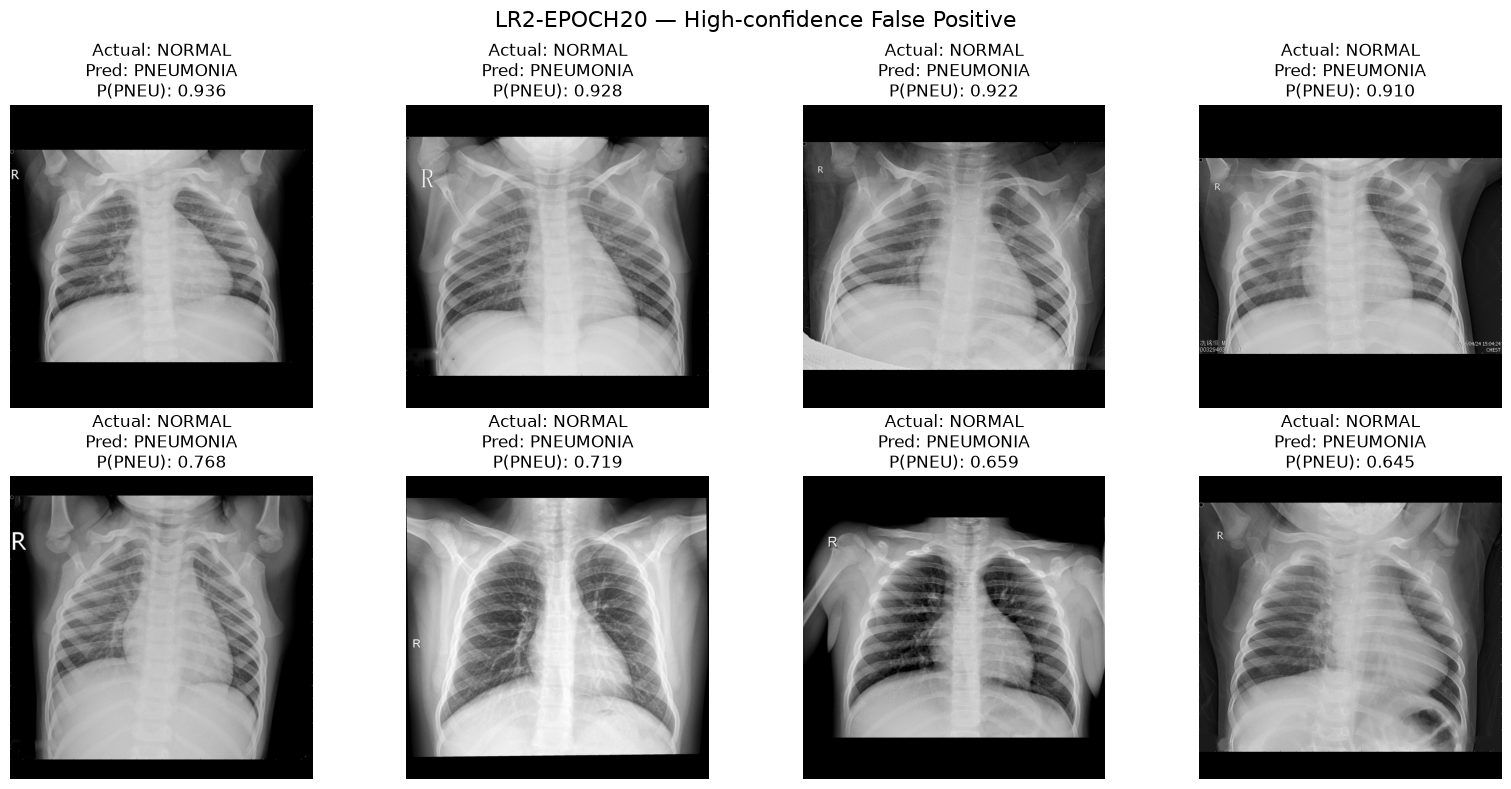

In [29]:
 # ============================================================
# 7-2-1. High-confidence False Positive
# ============================================================

cxp_plot.show_error_images(
    dataframe=fp_high_conf,
    data_dir=DATASET_TRAIN_DIR,
    idx_to_class=IDX_TO_CLASS,
    n=8,
    title=f"{ERROR_RUN} — High-confidence False Positive",
)

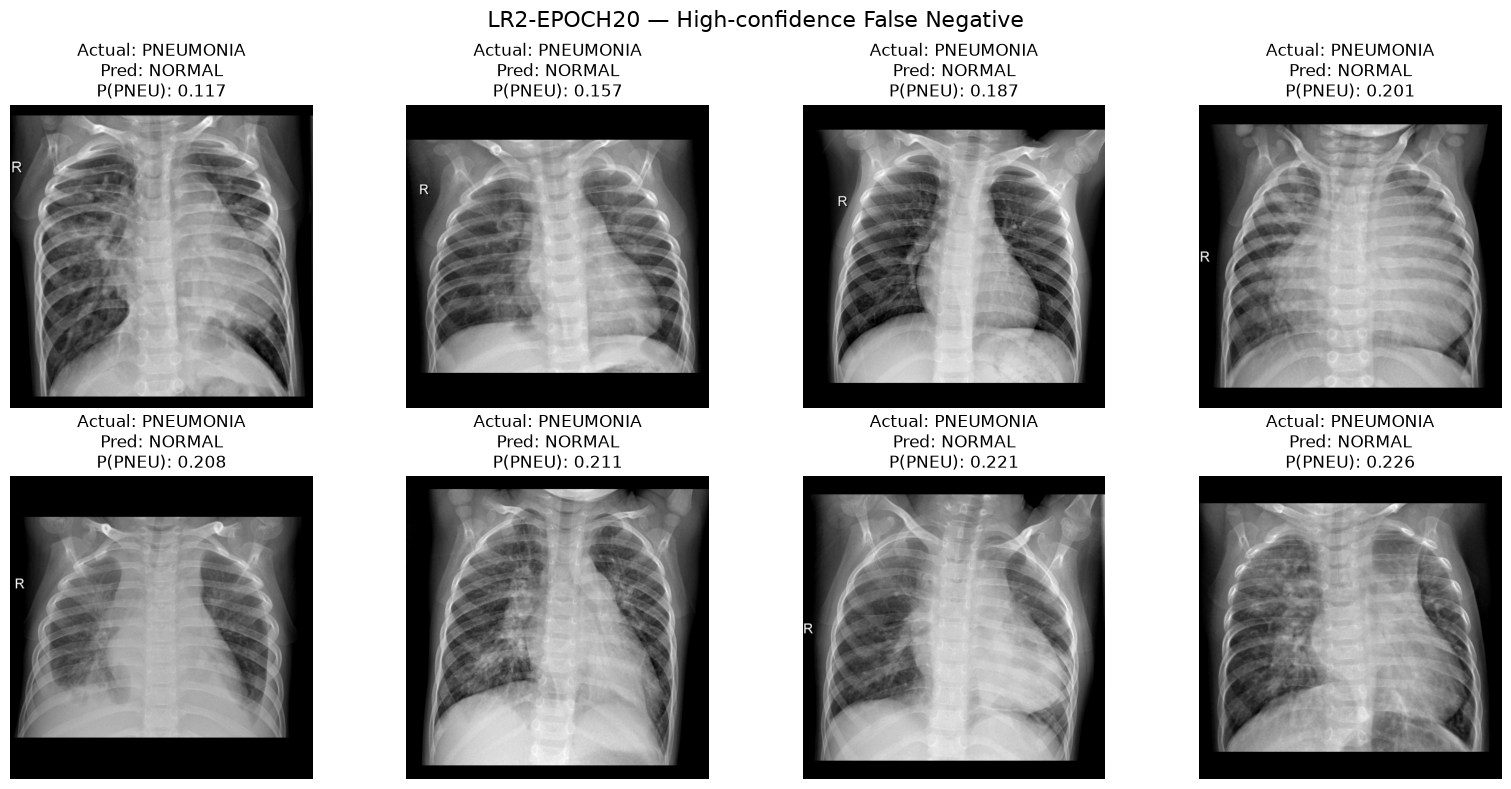

In [30]:
# ============================================================
# 7-2-2. High-confidence False Negative
# ============================================================

cxp_plot.show_error_images(
    dataframe=fn_high_conf,
    data_dir=DATASET_TRAIN_DIR,
    idx_to_class=IDX_TO_CLASS,
    n=8,
    title=f"{ERROR_RUN} — High-confidence False Negative",
)

#### 7-3 Grad-CAM

In [50]:
# ============================================================
# 7-3. Grad-CAM
# ============================================================

import importlib
import cxp.cxp_gradcam as cxp_gradcam

importlib.reload(cxp_gradcam)

<module 'cxp.cxp_gradcam' from 'D:\\DEV\\AI\\projects\\chest-xray-pneumonia\\cxp\\cxp_gradcam.py'>

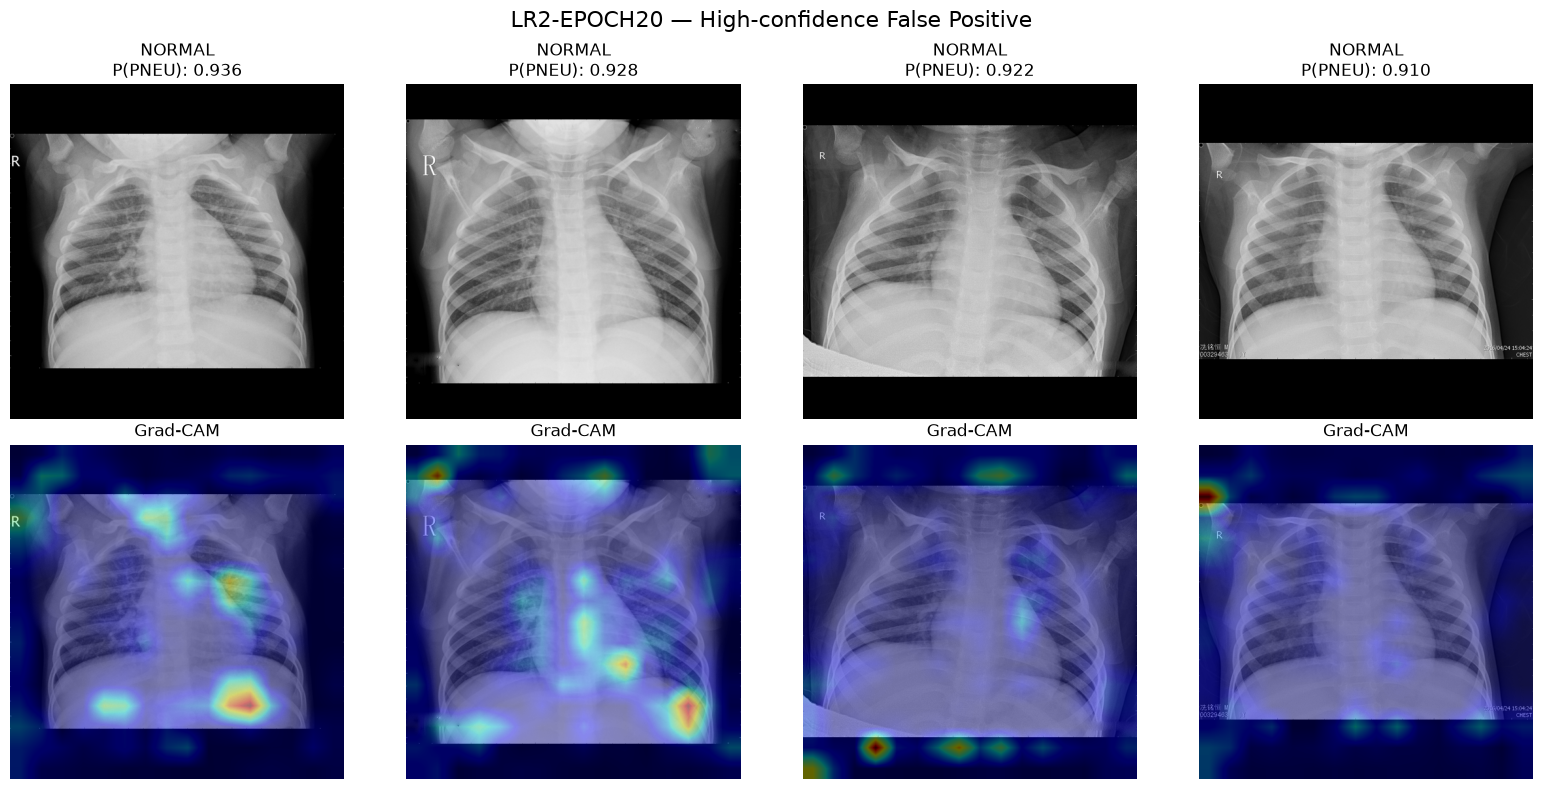

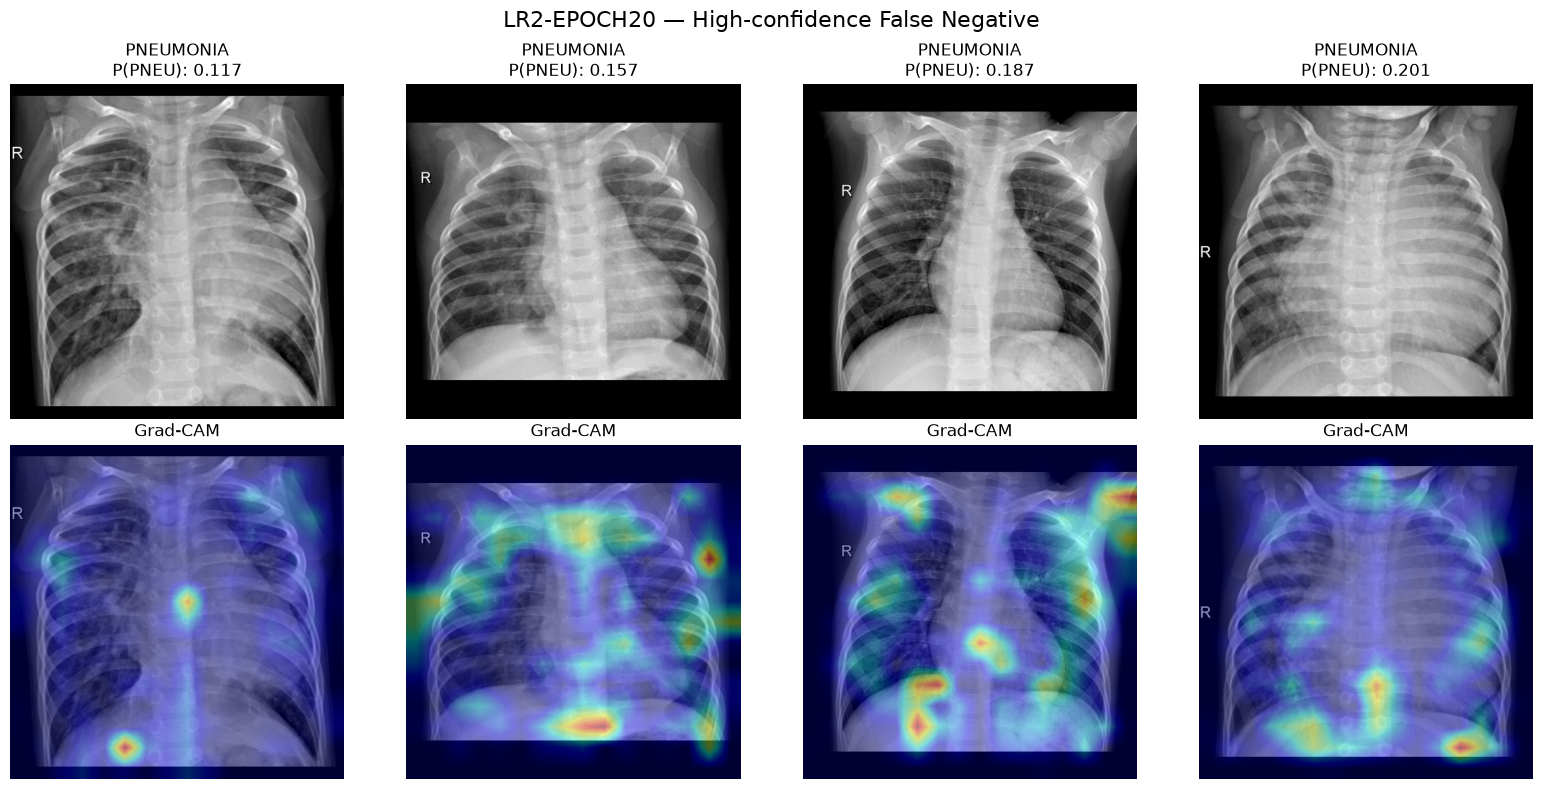

In [31]:
# ============================================================
# 7-3-2. FP / FN Grad-CAM Comparison
# ============================================================

from cxp import cxp_gradcam

GRADCAM_RUN = ERROR_RUN
N_SAMPLES = 4

run_info = selected_summary[
    selected_summary["run"] == GRADCAM_RUN
].iloc[0]

model = load_experiment_model(run_info)

target_layer = cxp_gradcam.get_gradcam_target_layer(
    model=model,
    model_name=run_info["model"],
)

gradcam = cxp_gradcam.GradCAM(
    model=model,
    target_layer=target_layer,
)

eval_transform = create_transform(
    image_size=IMAGE_SIZE,
    mean=NORMALIZATION["mean"],
    std=NORMALIZATION["std"],
)

cxp_gradcam.plot_gradcam_samples(
    dataframe=fp_high_conf,
    gradcam=gradcam,
    transform=eval_transform,
    image_dir=DATASET_TRAIN_DIR,
    n_samples=N_SAMPLES,
    title_prefix=f"{GRADCAM_RUN} — High-confidence False Positive",
    device=DEVICE,
)

cxp_gradcam.plot_gradcam_samples(
    dataframe=fn_high_conf,
    gradcam=gradcam,
    transform=eval_transform,
    image_dir=DATASET_TRAIN_DIR,
    n_samples=N_SAMPLES,
    title_prefix=f"{GRADCAM_RUN} — High-confidence False Negative",
    device=DEVICE,
)

cxp_gradcam.cleanup_gradcam(
    gradcam=gradcam,
    model=model,
)

***Grad-CAM 기반 Error Analysis*** 

False Positive 사례에서 Grad-CAM을 확인한 결과, 활성 영역이 폐 실질에만 집중되지 않고 심장·종격동, 하부 흉부 및 영상 가장자리 등 여러 영역에 분산되는 사례가 확인되었다.

일부 사례에서는 PNEUMONIA 확률이 0.9 이상으로 높게 나타났으며, 모델이 폐렴 관련 특징 외에 영상의 배경이나 촬영 특성에 영향을 받았을 가능성도 확인하였다.

단, Grad-CAM은 모델의 예측에 영향을 준 영역을 시각화하는 도구이므로 실제 병변 위치나 의학적 판단 근거로 해석하지 않았다.

#### 7-4 Error Analysis

Validation set 1,044개에서 Correct 978, FP 25, FN 41이 발생하였다.

- **FP:** 일부 사례에서 높은 확신으로 NORMAL을 PNEUMONIA로 예측
- **FN:** FP보다 많았으며, 일부 사례에서 PNEUMONIA 확률이 낮게 나타남
- **Grad-CAM:** 일부 오류 사례에서 활성 영역이 특정 폐 영역에 집중되지 않고 흉부 여러 영역에 분산됨

Grad-CAM은 모델의 예측에 영향을 준 영역을 시각화하는 도구이므로 실제 병변 위치나 의학적 판단 근거로 해석하지 않았다.

#### ----------------------------------------------------------------------------------------------------------------------------------------------------

### 8. Experiment Comment

#### Experiment Objective

**ResNet50 Frozen Transfer Learning에서 Learning Rate에 따른 성능 차이를 비교한다.**

* Model: ResNet50

* Training Mode: Frozen

* Optimizer: Adam

* Epochs: 10 / 20

* Input Size: 512 × 512

* Normalization: ImageNet Mean / Std

* Loss: CrossEntropy

* Learning Rate: LR1 (1e-3) / LR2 (1e-4) / LR3 (1e-5) / LR2-EPOCH20 (1e-4)

#### Result

| Metric      |    LR1 |    LR2 | LR2-EPOCH20 |    LR3 |
| ----------- | -----: | -----: | ----------: | -----: |
| Accuracy    | 0.9540 | 0.9186 |      0.9368 | 0.7433 |
| Precision   | 0.9740 | 0.9458 |      0.9671 | 0.7433 |
| Recall      | 0.9639 | 0.9446 |      0.9472 | 1.0000 |
| Specificity | 0.9254 | 0.8433 |      0.9067 | 0.0000 |
| F1          | 0.9689 | 0.9452 |      0.9570 | 0.8527 |
| ROC-AUC     | 0.9907 | 0.9715 |      0.9814 | 0.8264 |
| FP          |     20 |     42 |          25 |    268 |
| FN          |     28 |     43 |          41 |      0 |

#### Interpretation

* ****LR1:**** 가장 높은 Validation 성능을 보였으나 Learning Curve에서 일부 변동이 나타남

* ****LR2:**** LR1보다 성능은 낮지만 상대적으로 안정적인 학습 흐름

* ****LR2-EPOCH20:**** LR2와 동일한 Learning Rate에서 Epoch을 20으로 확장했으며, LR2보다 Validation 성능이 개선됨

* ****LR3:**** 학습이 충분히 진행되지 않아 성능 저하

* ****Error Analysis:**** LR2-EPOCH20에서 FP 25, FN 41이 발생했으며, 일부 오류 사례에서 Grad-CAM 활성 영역이 특정 폐 영역에 명확하게 집중되지 않음

#### Decision

****Selected Learning Rate: LR2 (1e-4)****

LR1의 높은 성능보다는 ****학습 안정성을 고려하여 LR2를 다음 실험의 Learning Rate로 선택한다.****

#### Next Experiment

선정한 ****LR2 (1e-4)****를 고정하고 다음 Transfer Learning 실험을 진행한다.
